# MNIST Transfer Learning with EfficientNet, BiT, MLP-Mixer, and ConvNeXt v2

In [16]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns

## Load Data Samples

In [17]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
x_train, y_train = x_train[:5000], y_train[:5000]
x_test, y_test = x_test[:1000], y_test[:1000]

## Preprocess

In [18]:
# Preprocess to flat vectors
x_train = x_train.reshape(-1, 28*28) / 255.0
x_test = x_test.reshape(-1, 28*28) / 255.0

## Train Classifier

In [19]:
# Train a simple classifier
clf = LogisticRegression(max_iter=1000)
clf.fit(x_train, y_train)
y_pred = clf.predict(x_test)

## Accuracy

In [20]:
# Accuracy
acc = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {acc:.2f}")

Test Accuracy: 0.88


## Classification report

In [21]:
# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.95      0.94        85
           1       0.96      0.99      0.98       126
           2       0.89      0.83      0.86       116
           3       0.88      0.81      0.84       107
           4       0.92      0.90      0.91       110
           5       0.81      0.82      0.81        87
           6       0.92      0.90      0.91        87
           7       0.82      0.87      0.84        99
           8       0.82      0.84      0.83        89
           9       0.85      0.89      0.87        94

    accuracy                           0.88      1000
   macro avg       0.88      0.88      0.88      1000
weighted avg       0.88      0.88      0.88      1000



## Confusion matrix

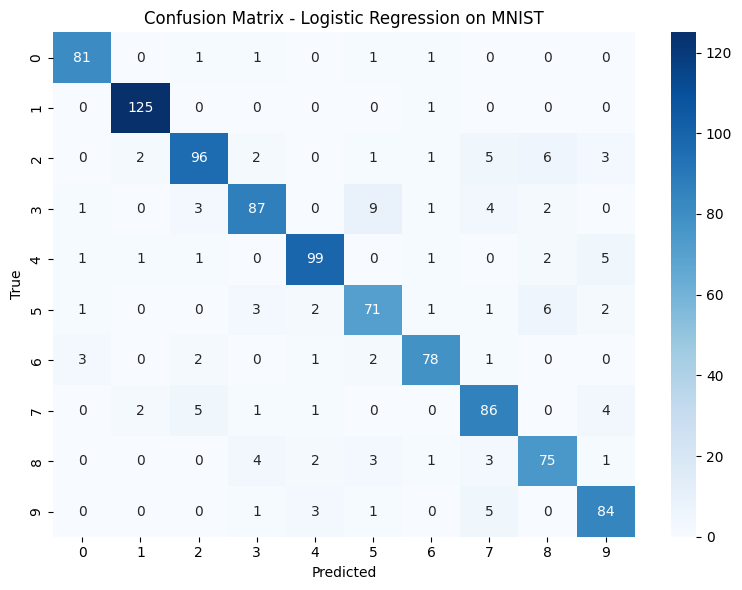

In [22]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=range(10), yticklabels=range(10))
plt.title("Confusion Matrix - Logistic Regression on MNIST")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

## Visualization of predictions

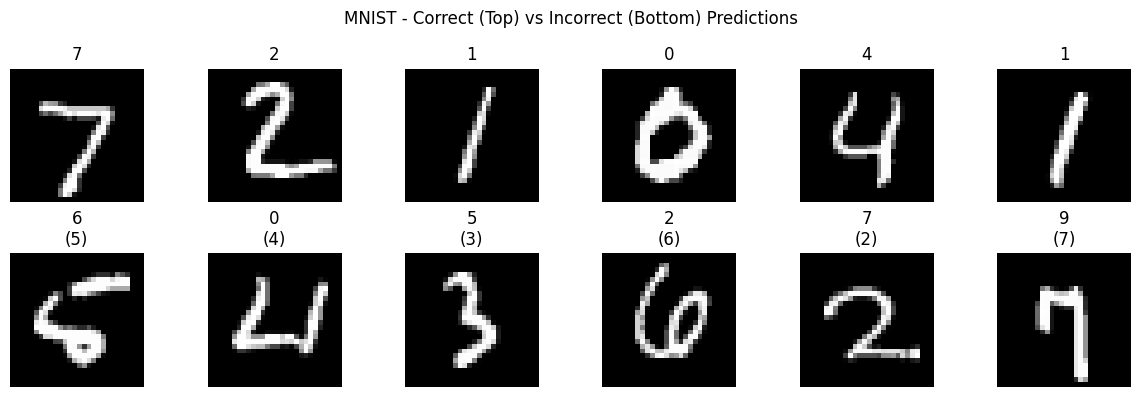

In [23]:
# Visualization of predictions
correct = np.where(y_pred == y_test)[0][:6]
incorrect = np.where(y_pred != y_test)[0][:6]

plt.figure(figsize=(12, 4))
for idx, i in enumerate(correct):
    plt.subplot(2, 6, idx+1)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    plt.title(f"{y_pred[i]}")
    plt.axis('off')
for idx, i in enumerate(incorrect):
    plt.subplot(2, 6, idx+7)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    plt.title(f"{y_pred[i]}\n({y_test[i]})")
    plt.axis('off')
plt.suptitle("MNIST - Correct (Top) vs Incorrect (Bottom) Predictions")
plt.tight_layout()
plt.show()

#accuracy bar plot

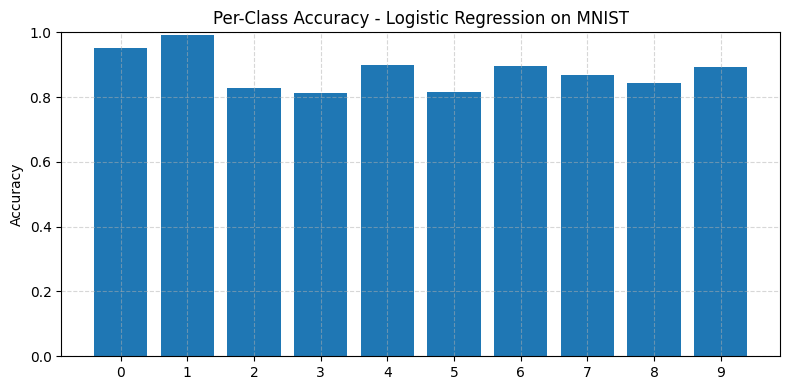

In [24]:
# Per-class accuracy bar plot
per_class_accuracy = cm.diagonal() / cm.sum(axis=1)
plt.figure(figsize=(8, 4))
plt.bar(range(10), per_class_accuracy)
plt.xticks(range(10))
plt.ylim(0, 1)
plt.ylabel("Accuracy")
plt.title("Per-Class Accuracy - Logistic Regression on MNIST")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()